# 05 — Results: deliverable figures + the headline table

Read-only over a completed run dir — no engine state, no CWD cache, no re-attach; loads in
about a minute and every cell re-renders in seconds. Re-run freely while writing the paper;
notebooks 01–04 are the production pipeline and never need to be touched for figure work.

Figures land in the run dir's `figures/` (provenance stays with the run). Naming discipline
(D11/D15): the slack surface is *near-optimality*, the ensemble surface is *attribution* —
neither is a "selection frequency".


In [1]:
# ---- Setup: find the project root, import the shared engine ------------------
import sys, pathlib
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
          if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))

import importlib
import config
import corridors_core as cc
for _m in (config, cc):
    importlib.reload(_m)

RUN = "v2_run002"                      # <-- the run to render
R = cc.load_results(config.RESULTS_DIR / "corridors_north" / RUN)


v2_run002: results context loaded (58 edges, 41 branches, corridor 33,041 km²)


## Near-optimality surface (D11) — input + two standalone figures

First the INPUT, paired with the footprint index it replaced: the full movement-cost surface
(4 ordinal classes, log colour, class shares in the title) beside raw Theobald gHM at the 1 km
audit grid — the visual case for D2/A2 (roads survive as continuous barriers at 300 m; 1 km
gHM smears them toward invisibility). Reading note for the gHM panel: the colour is
POWER-scaled because the layer is heavy-tailed — the pale-to-orange range spans only ~0–0.1;
don't read the northern wash as moderate modification. Then the two products: the slack
surface (raw cost units, log colour) and the pre-registered tiers. Proposed IPCAs are burnt
orange on the product figures — the house teal vanishes into the viridis ramp and tier greens.


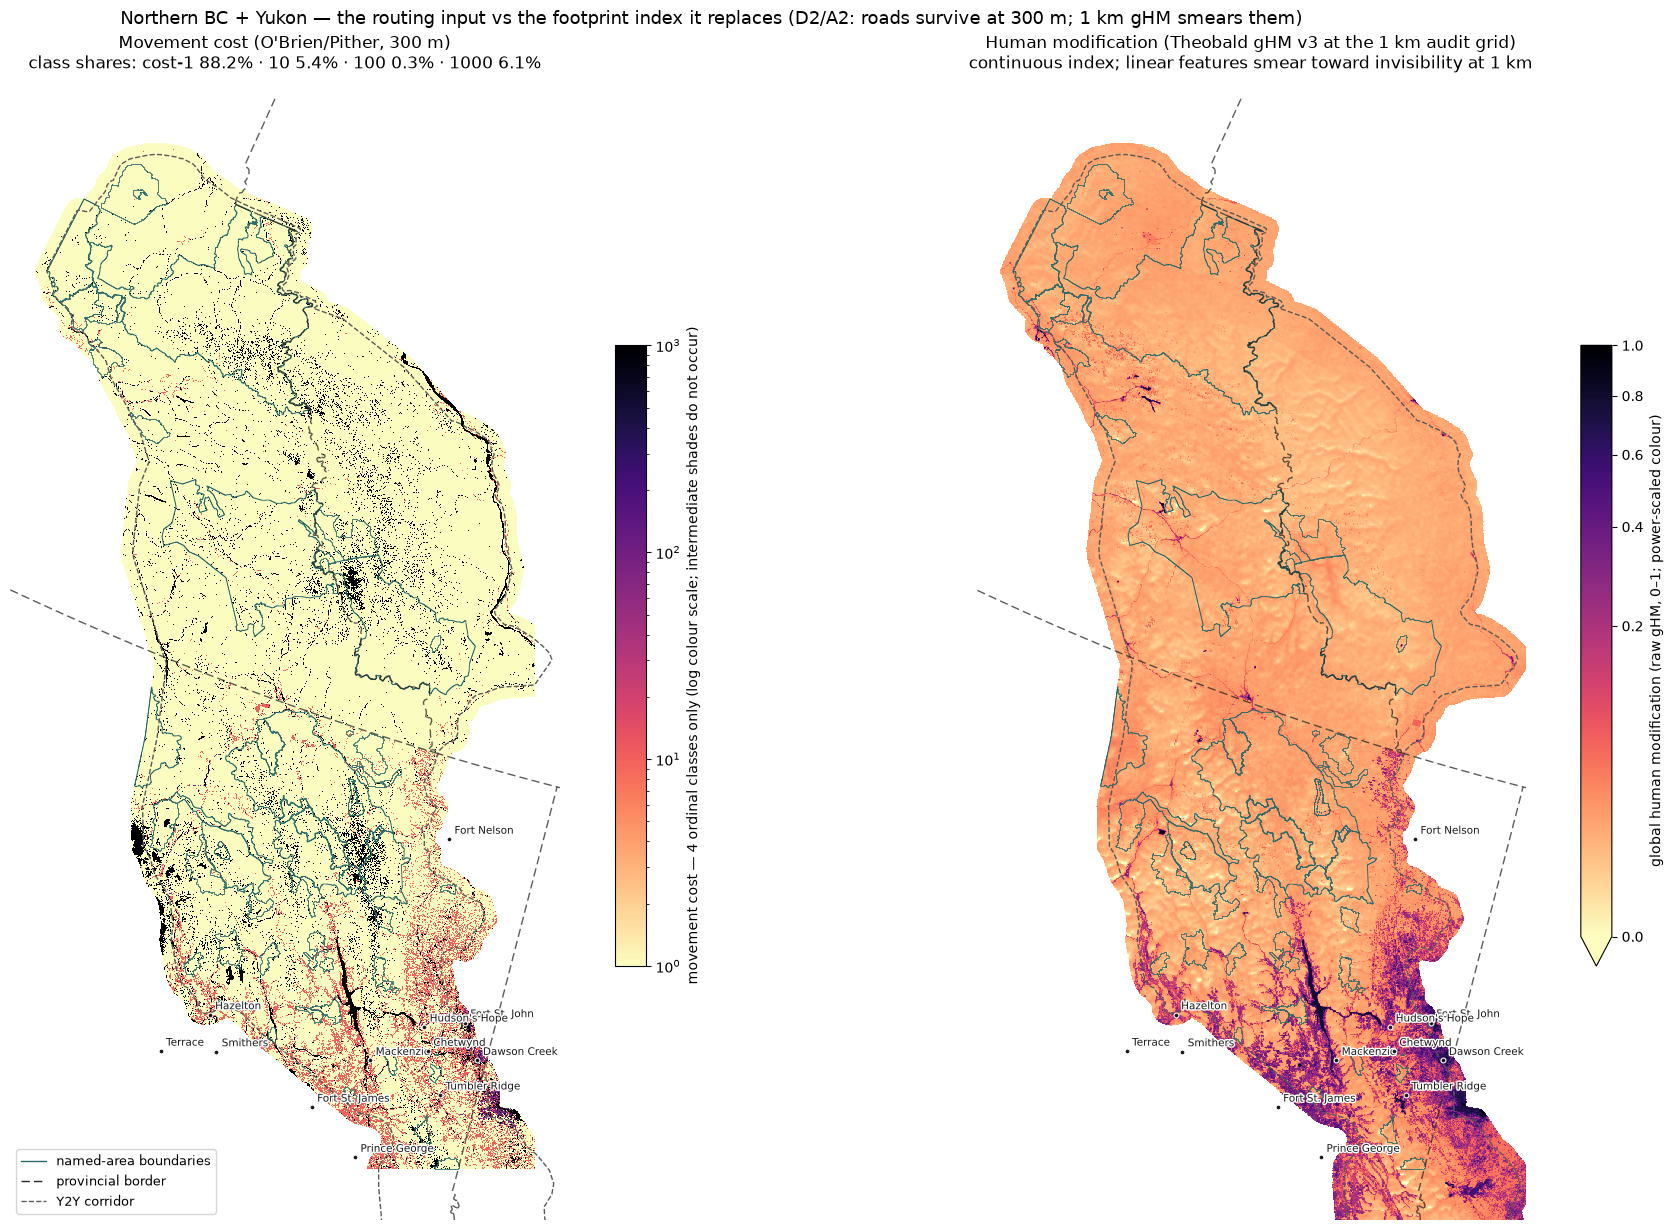

<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>

In [2]:
cc.cost_surface_map(R)


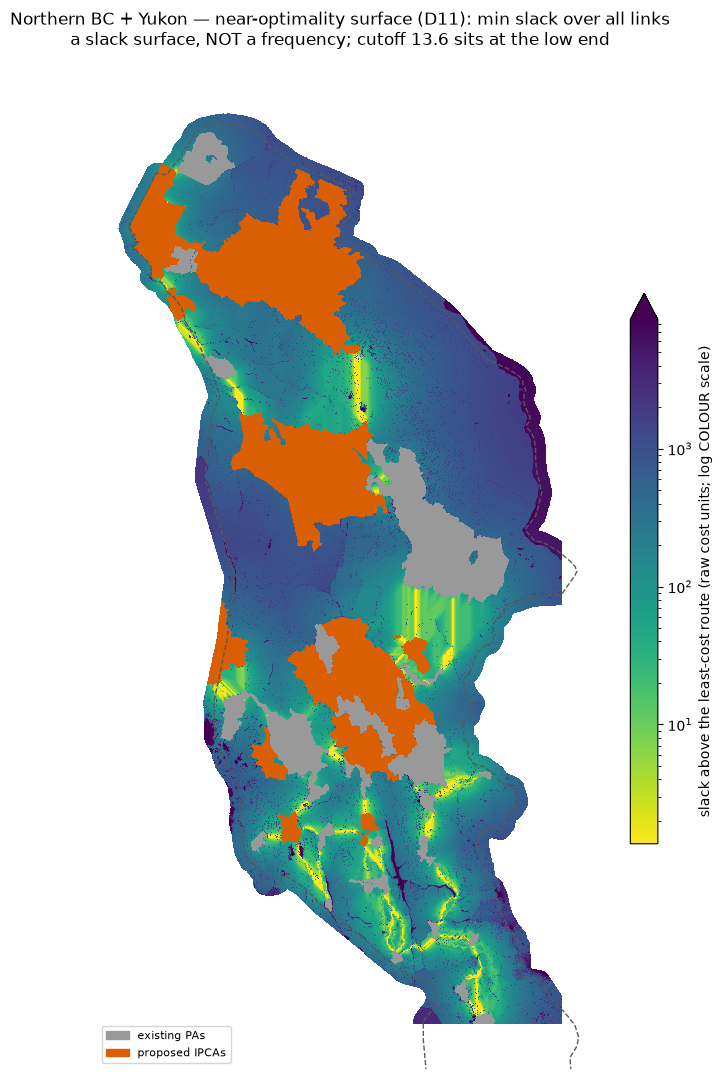

<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>

In [3]:
cc.near_opt_map(R)


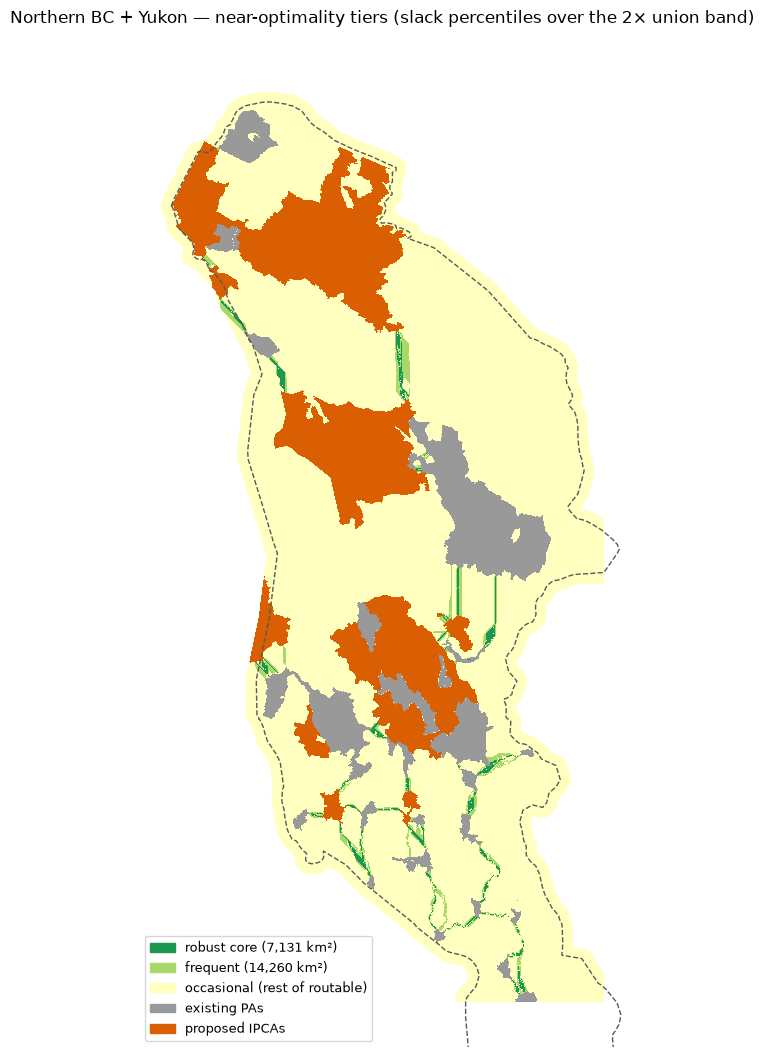

<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>

In [4]:
cc.near_opt_tiers_map(R)


### Presentation variant (board audience)

Separate output (`near_optimality_map_board.png`) — plain-language title/labels, no decision
codes, structural-claim caveat as a footnote. The science figure above is untouched. Title,
subtitle and footnote are parameters if the framing needs adjusting for a given deck.


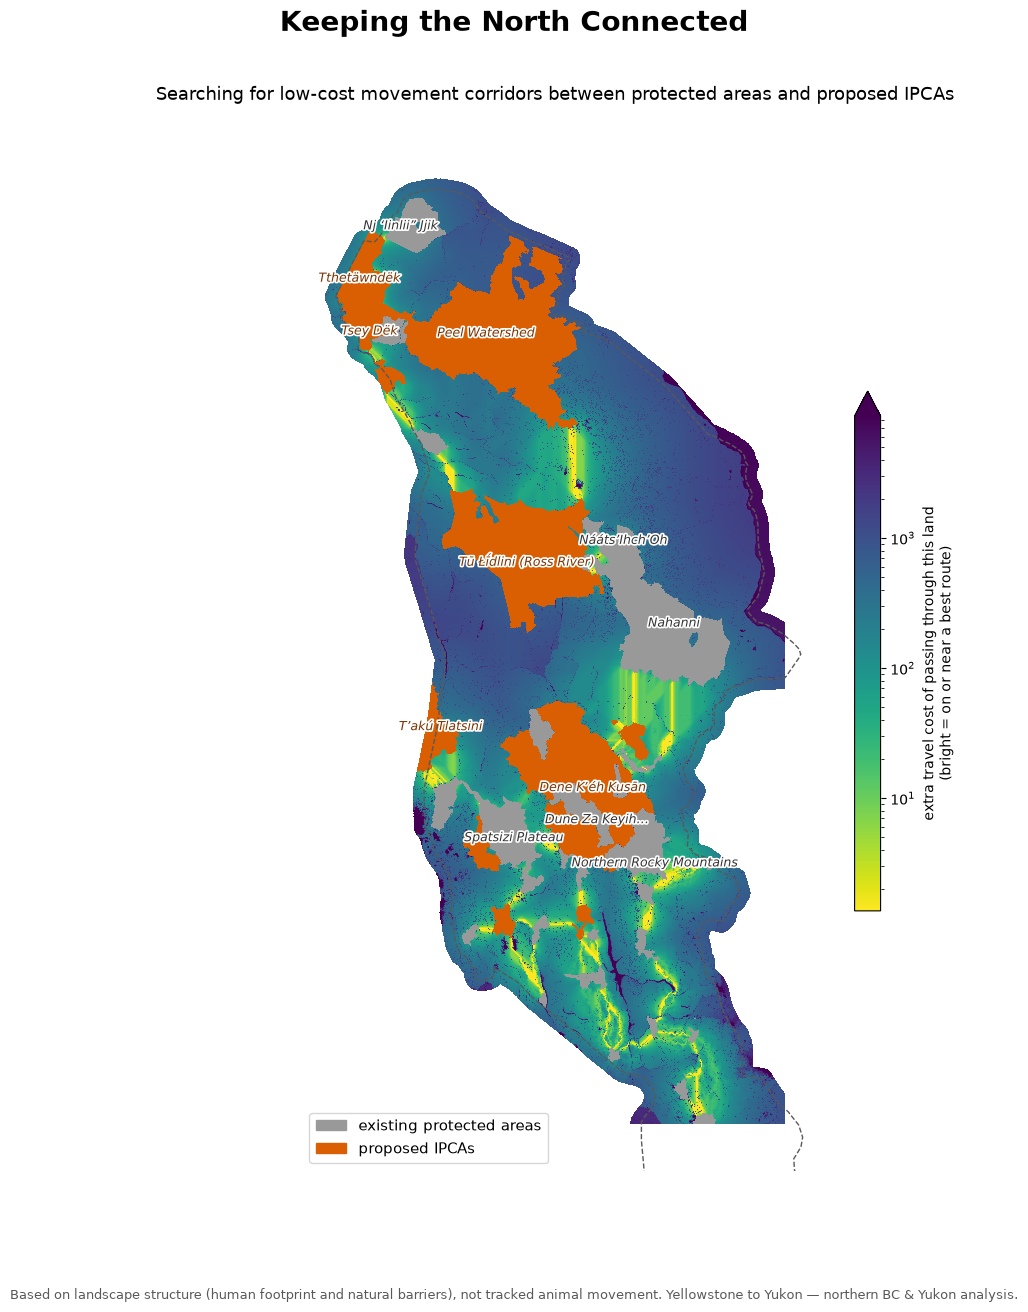

<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>

In [5]:
cc.near_opt_map_board(R)


## Ensemble attribution + per-axis panels (D15)

The robust-core contour rides on the all-members panel; the three axis panels say *which
assumption* the fragile areas hang on — band width, one unrealized proposal, or the β ceiling.


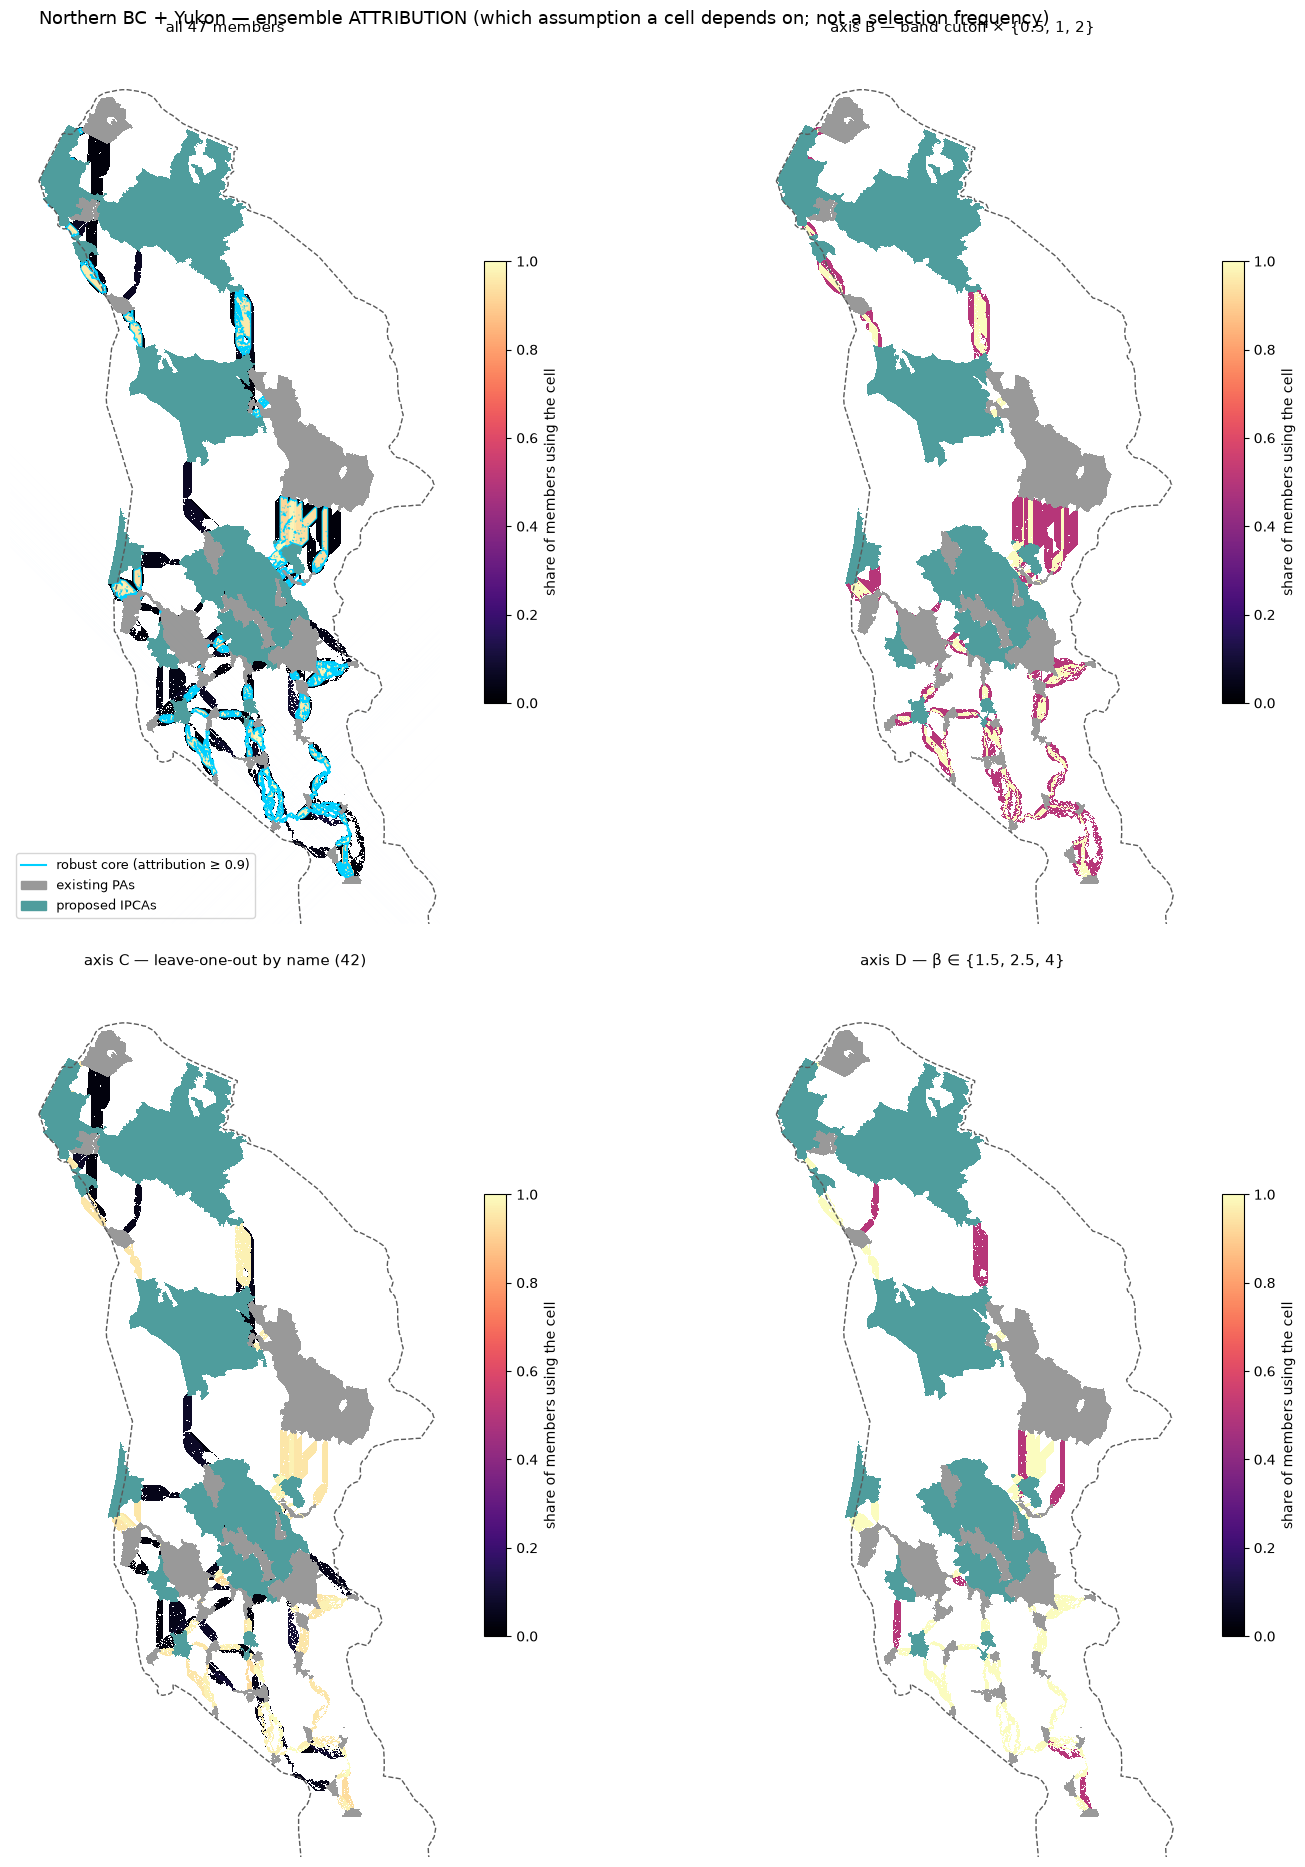

<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>

In [6]:
cc.attribution_map(R)


## Route branches (D12)

Route-irreplaceable branch land in the muted tone; the three links with genuine alternatives
highlighted (primary branch solid, alternative lighter) — the map companion to `tiebreak.csv`.


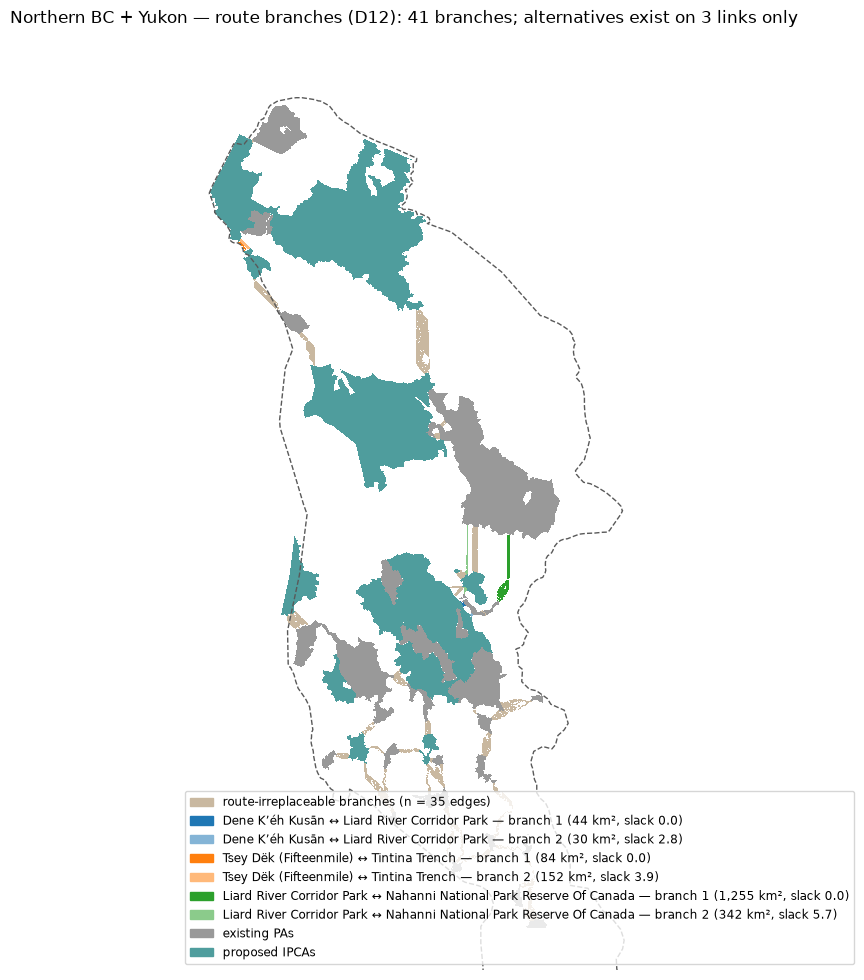

<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>

In [7]:
cc.branches_map(R)


## Routing problem vs securing problem (M1.4 / M4.6)

The near-Euclidean mechanism means most corridor land sits in the SECURING regime — the
landscape still offers alternatives, and the ask is to keep some of them. This figure isolates
the exceptions, where connectivity is a genuine ROUTING problem: red = irreplaceable in both
senses (no alternative link, no alternative routing); orange = edge-irreplaceable (D7);
gold = squeezed links whose band is under half its open-ground ellipse width (the landscape,
not geometry, confines the corridor). The returned table lists the non-grey links with
`squeeze_idx` and `cost_per_km` (3.3 = pure intact land; NaN for near-touching pairs).


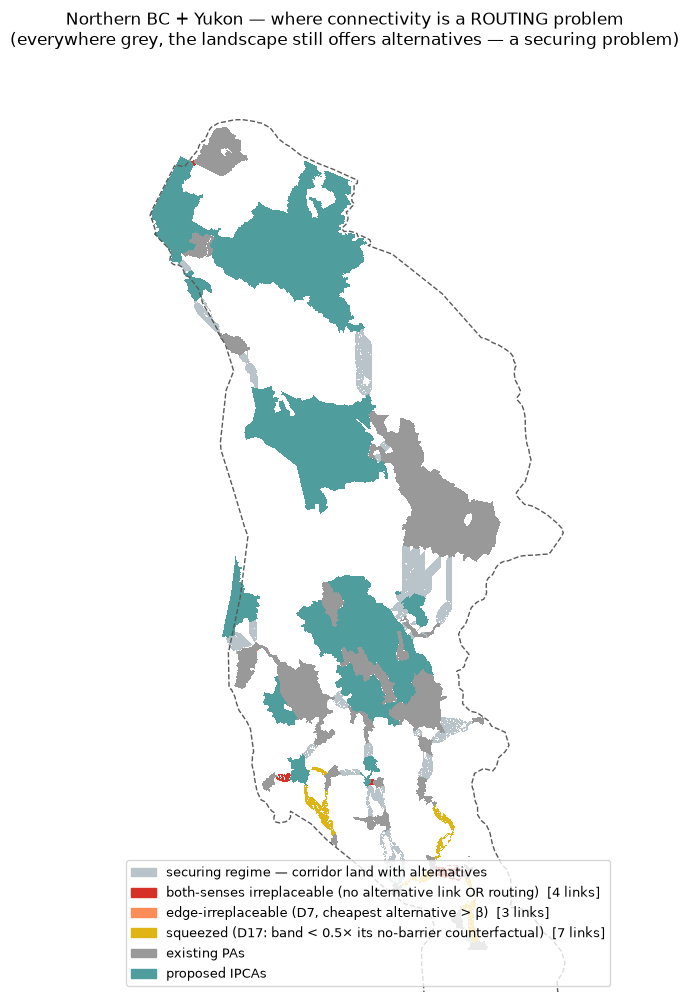

,label_i,label_j,squeeze_idx,cost_per_km,irreplaceable,backup_ratio,n_branches
edge_id,,,,,,,
E019_024,PA · Gwillim Lake Park,PA · Monkman Park,0.35,4.7,False,1.479260,1
E018_033,PA · Graham Laurier Park,PA · Pine Le Moray Park,0.38,4.9,False,NaN,1
E010_033,PA · Carp Lake Park,PA · Pine Le Moray Park,0.44,5.3,False,NaN,1
E019_020,PA · Gwillim Lake Park,PA · Kakwa Park,0.44,4.3,False,NaN,1
E025_038,PA · Mount Blanchet Park,PA · Sustut Park,0.48,4.2,False,1.074247,1
E005_025,IPCA · Wilps Gwininitxw,PA · Mount Blanchet Park,0.71,4.1,False,NaN,1
E005_038,IPCA · Wilps Gwininitxw,PA · Sustut Park,0.72,4.0,False,NaN,1
E019_033,PA · Gwillim Lake Park,PA · Pine Le Moray Park,0.82,4.2,True,2.555613,1
E005_039,IPCA · Wilps Gwininitxw,PA · Swan Lake Kispiox River Park,1.37,3.5,True,3.952485,1


In [8]:
cc.routing_problem_map(R)


### Zoom — the southern routing-problem cluster, labelled

Frames the routing-regime links in the lower window (a display choice: links with corridor
centroid below 40% of the map height; Tatonduk ↔ Fishing Branch stays on the full-extent map).
Named areas labelled (IPCAs teal italic, PAs grey); links numbered north → south, keyed to the
legend with squeeze, backup ratio and the ABSOLUTE replacement cost in intact-land km — the
ratio alone misleads for near-touching pairs (M4.5).


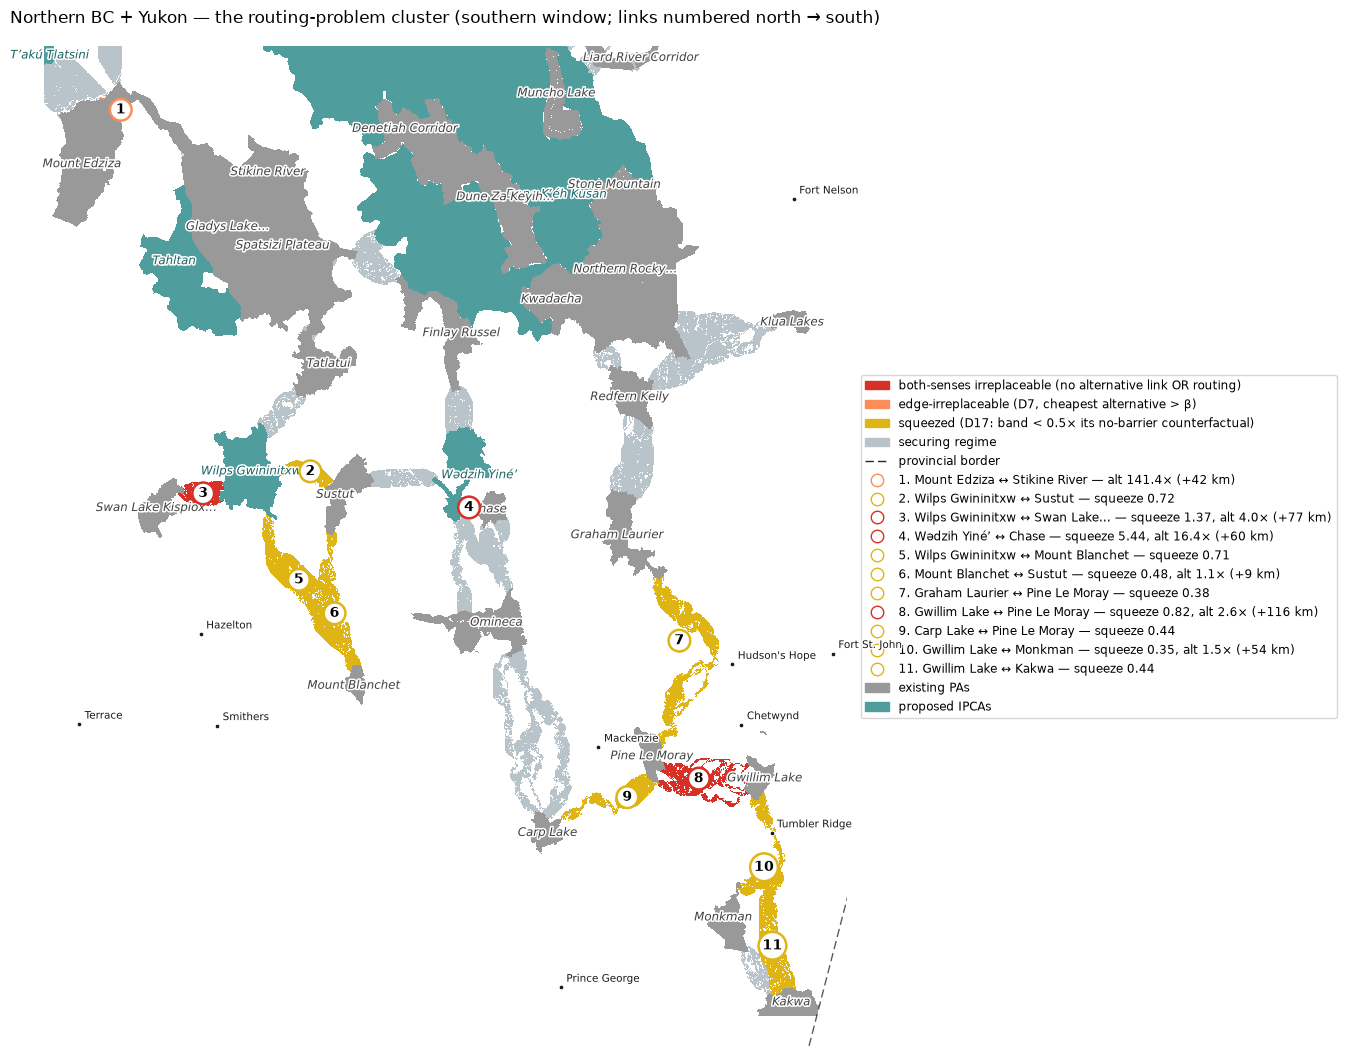

<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>

In [9]:
cc.routing_problem_zoom(R)


### The cluster against its cause — cost | links | overlay

Same frame, three views: the movement-cost surface (the region-wide "88% cost-1" does NOT hold
in this window — the Peace-country road network and Williston Reservoir dominate), the
classified links, and the overlay (cost in greys under the class colours, named-area
boundaries outlined). The overlay is the one-glance argument for why this cluster is the
routing problem: the flagged corridors thread between dense barrier fields.


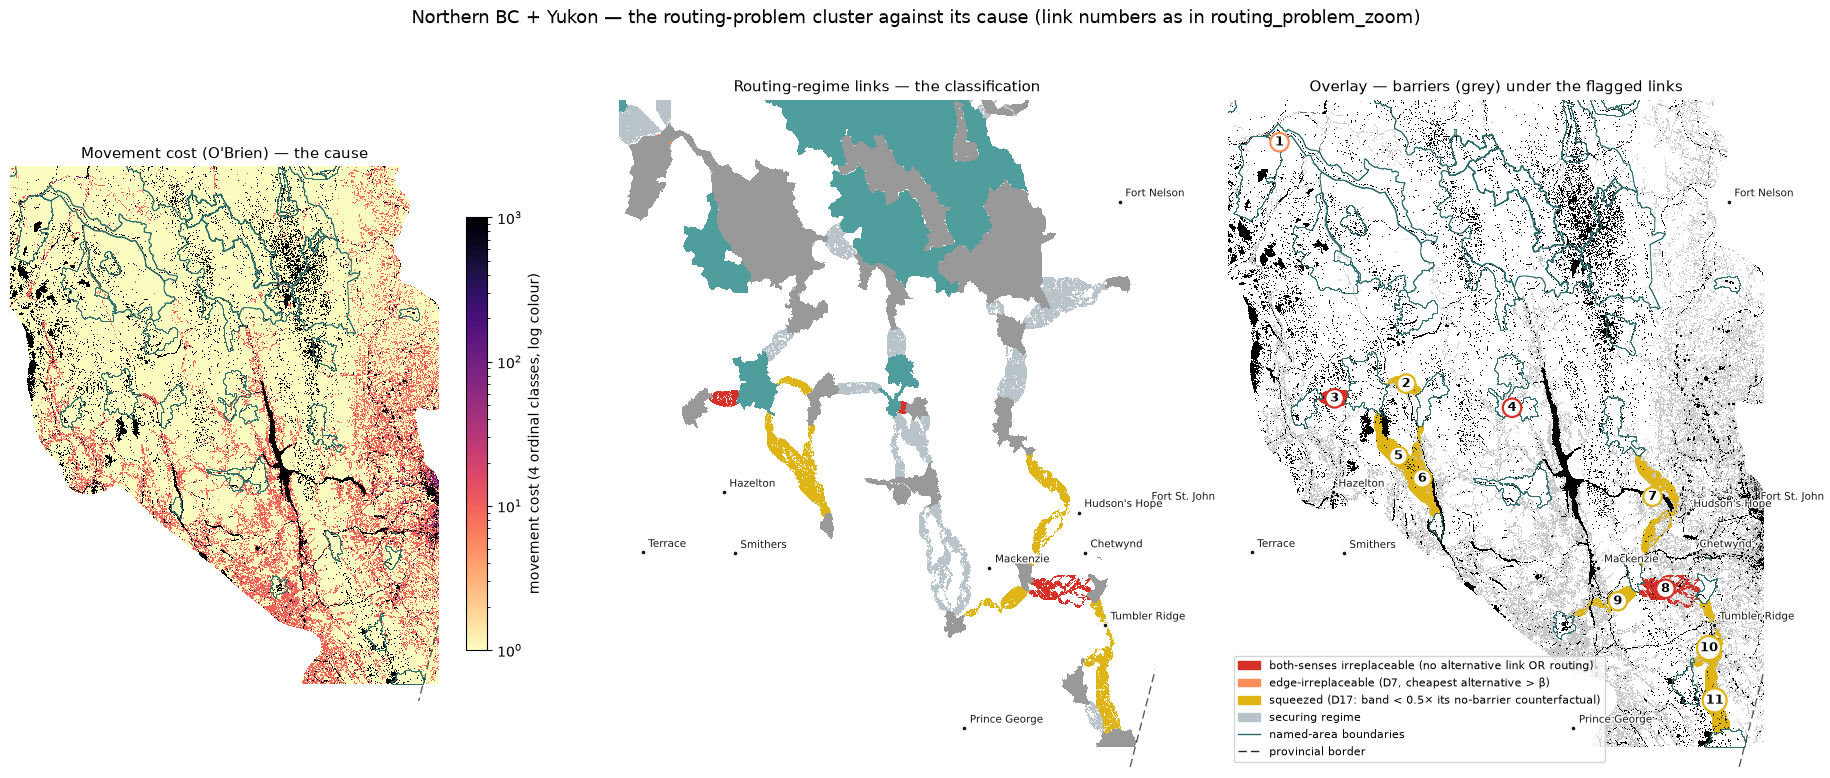

<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>

In [10]:
cc.routing_problem_cost_zoom(R)


### Flagged links directly on the cost surface

Anchors + flagged corridors hard-coloured; every other cell shows its movement-cost value —
so the in-between land reads as the live cost surface. The candidate headline figure: the
flagged corridors occupy the remaining cost-1 gaps between the Peace-country road lattice
(red) and Williston Reservoir (black). `show_securing=True` adds the securing-regime corridor
in light grey if wanted.


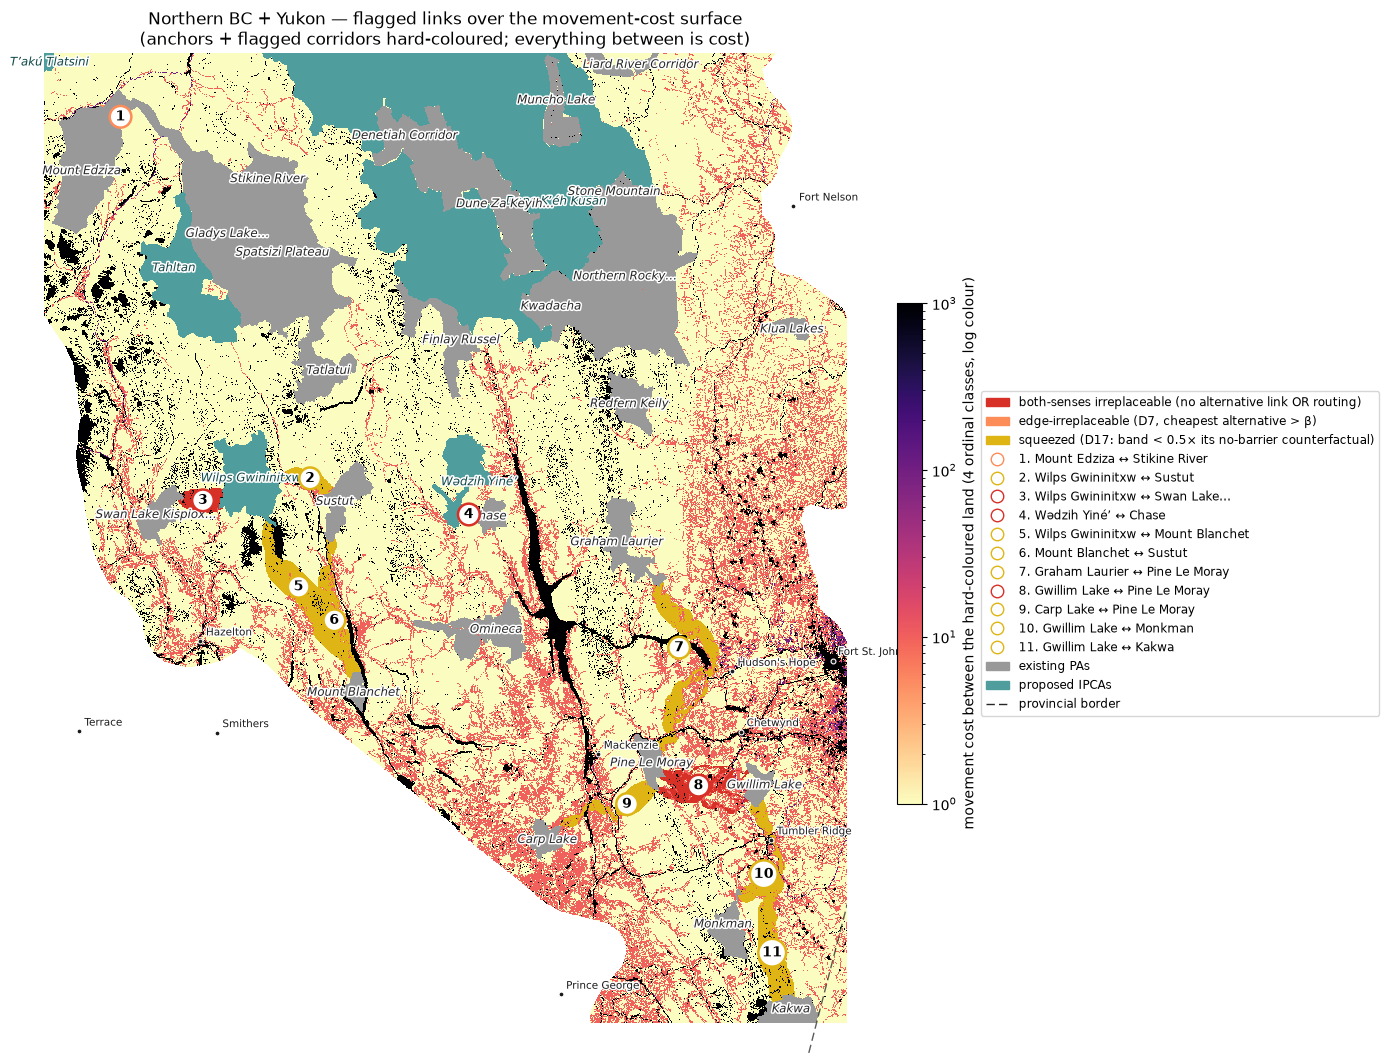

<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>

In [11]:
cc.routing_problem_cost_overlay(R)


## Irreplaceability summary — the headline table

One row per non-adjacency edge, joining the D7 β-ceiling flag, the D12 route-branch count, and
ensemble presence. The rows flagged in BOTH senses are the strongest criticality statement the
analysis makes: no alternative link at any reasonable price AND no alternative routing within
the link. Written to `irreplaceability_summary.csv` in the run dir.


In [12]:
t = cc.irreplaceability_table(R)
t.head(20)


irreplaceability_summary.csv: 45 edges | 7 edge-irreplaceable (D7) | 35 route-irreplaceable (D12) | 4 BOTH -- the land with no alternative link AND no alternative routing


,label_i,label_j,edge_class,cost,in_mst,ecfb_raw,irreplaceable,backup_ratio,backup_extra_km_equiv,disconnects,n_pairs_lost,cost_inflation,n_branches,route_irreplaceable,width_km,squeeze_idx,cost_per_km,presence_freq,band_km2
edge_id,,,,,,,,,,,,,,,,,,,
E019_033,PA · Gwillim Lake Park,PA · Pine Le Moray Park,inter,248.929977,True,39.000000,True,2.555613,116.0,True,117,inf,1,True,14.5,0.82,4.2,0.957,868.23
E006_016,IPCA · Tthetäwndëk (Tatonduk),PA · Nj ‘Iinlii” Jjik (Fishing Branch) Habitat...,inter,9.000000,True,14.000000,True,19.235538,49.0,True,41,inf,1,True,34.4,6.82,3.0,0.957,103.05
E005_039,IPCA · Wilps Gwininitxw,PA · Swan Lake Kispiox River Park,inter,86.556351,True,14.000000,True,3.952485,77.0,True,41,inf,1,True,16.0,1.37,3.5,0.957,397.71
E009_011,IPCA · Wədzih Yiné’ (Caribou Song),PA · Chase Park,inter,13.000000,True,34.315779,True,16.393834,60.0,False,0,29.681535,1,True,30.5,5.44,3.1,0.957,127.98
L025_027,PA · Liard River Corridor Park [part 1],PA · Liard River Corridor Park [part 3],intra_name,5.242640,True,NaN,True,4.644462,6.0,True,47,inf,0,False,NaN,NaN,NaN,NaN,47.79
E017_035,PA · Gladys Lake Ecological Reserve,PA · Spatsizi Plateau Wilderness Park,inter,1.000000,True,14.000000,True,46.899494,14.0,True,41,inf,0,False,NaN,NaN,NaN,0.957,659.61
E026_036,PA · Mount Edziza Park,PA · Stikine River Park,inter,1.000000,True,20.749866,True,141.350296,42.0,False,0,269.161476,0,False,NaN,NaN,NaN,0.957,146.61
L032_033,PA · Nahanni National Park Reserve Of Canada [...,PA · Nahanni National Park Reserve Of Canada [...,intra_name,36.485283,True,NaN,False,0.027408,-11.0,True,407,inf,1,True,24.5,3.08,3.5,NaN,256.77
L002_003,IPCA · Dene Kʼéh Kusān [part 2],IPCA · Dene Kʼéh Kusān [part 3],intra_name,48.769554,True,NaN,False,2.489196,22.0,True,47,inf,1,True,33.1,3.98,4.2,NaN,387.54


## Priority-link value profiles — star plots (PROACT consequences)

The nine numbered priority links through the same co-benefit star-plot analysis as the
corridor segments: richness / contribution / efficiency per input via `mask_profile` on the
1 km audit grid (0.5-majority crossing — the G5-anchored path, directly comparable with the
earlier corridor/IPCA/PA stars). Link land = the cells each link owns on the priority surface
(no double counting between overlapping bands); IPCA/PA reference stars appended for the gap
read. Same caveat as ever: links are routed for permeability, never for value — a low axis is
a finding, not a failure. Writes `priority_links_profile.csv` + three star figures. Note link
1 (Edziza ↔ Stikine) is a 12 km² contact zone — read its profile as indicative only.


  building 8 continuous + 20 EFG stacks on the 1000 m AUDIT grid…
  crossing masks 300 m -> 1 km for profiling:
  OK  audit grid: 1. Mount Edziza ↔ Stikine River 13 km² @300 m -> 12 km² @1 km (+6.1%)
  OK  audit grid: 2. Wilps Gwininit… ↔ Sustut 269 km² @300 m -> 265 km² @1 km (+1.4%)
  OK  audit grid: 3. Wilps Gwininit… ↔ Swan Lake… 366 km² @300 m -> 387 km² @1 km (+5.8%)
  OK  audit grid: 4. Wədzih Yiné’ ↔ Chase 79 km² @300 m -> 81 km² @1 km (+2.5%)
  OK  audit grid: 5. Wilps Gwininit… ↔ Mount Blanchet 1,175 km² @300 m -> 1,231 km² @1 km (+4.7%)
  OK  audit grid: 6. Mount Blanchet ↔ Sustut 753 km² @300 m -> 792 km² @1 km (+5.2%)
  OK  audit grid: 7. Graham Laurier ↔ Pine Le Moray 1,232 km² @300 m -> 1,274 km² @1 km (+3.4%)
  OK  audit grid: 8. Gwillim Lake ↔ Pine Le Moray 837 km² @300 m -> 859 km² @1 km (+2.7%)
  OK  audit grid: 9. Carp Lake ↔ Pine Le Moray 587 km² @300 m -> 602 km² @1 km (+2.5%)
  OK  audit grid: 10. Gwillim Lake ↔ Monkman 515 km² @300 m -> 518 km² @1 km (+0.5%)
  O

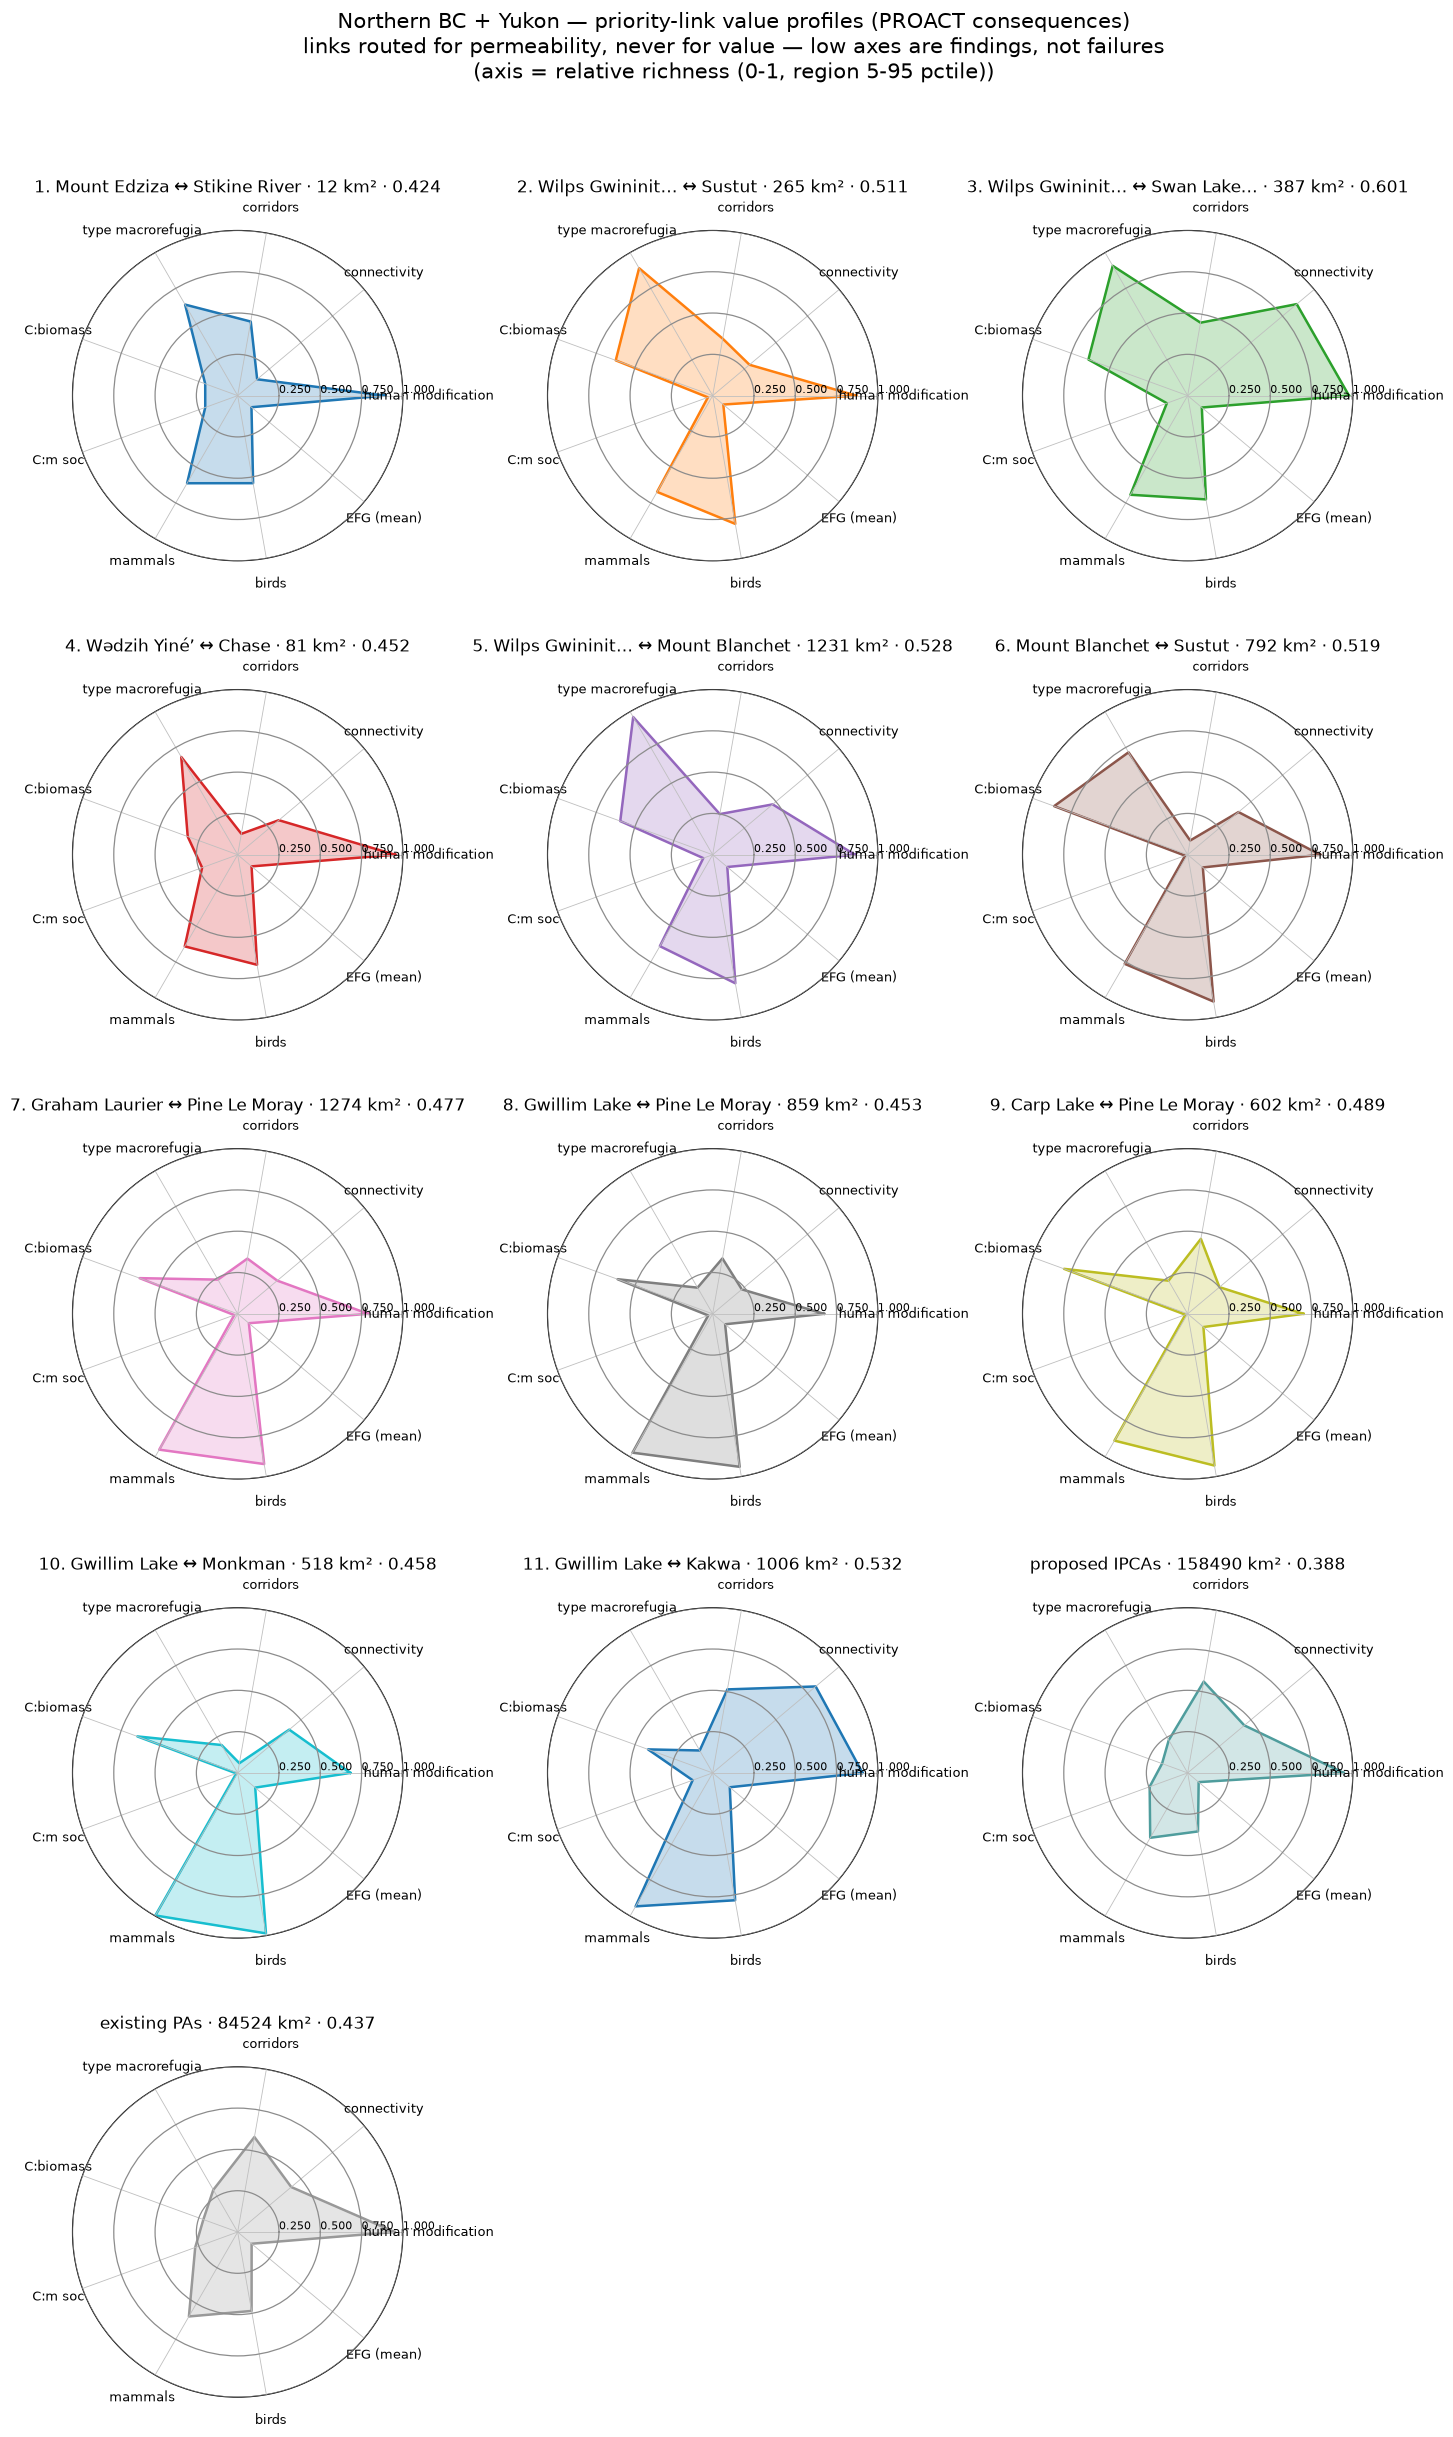

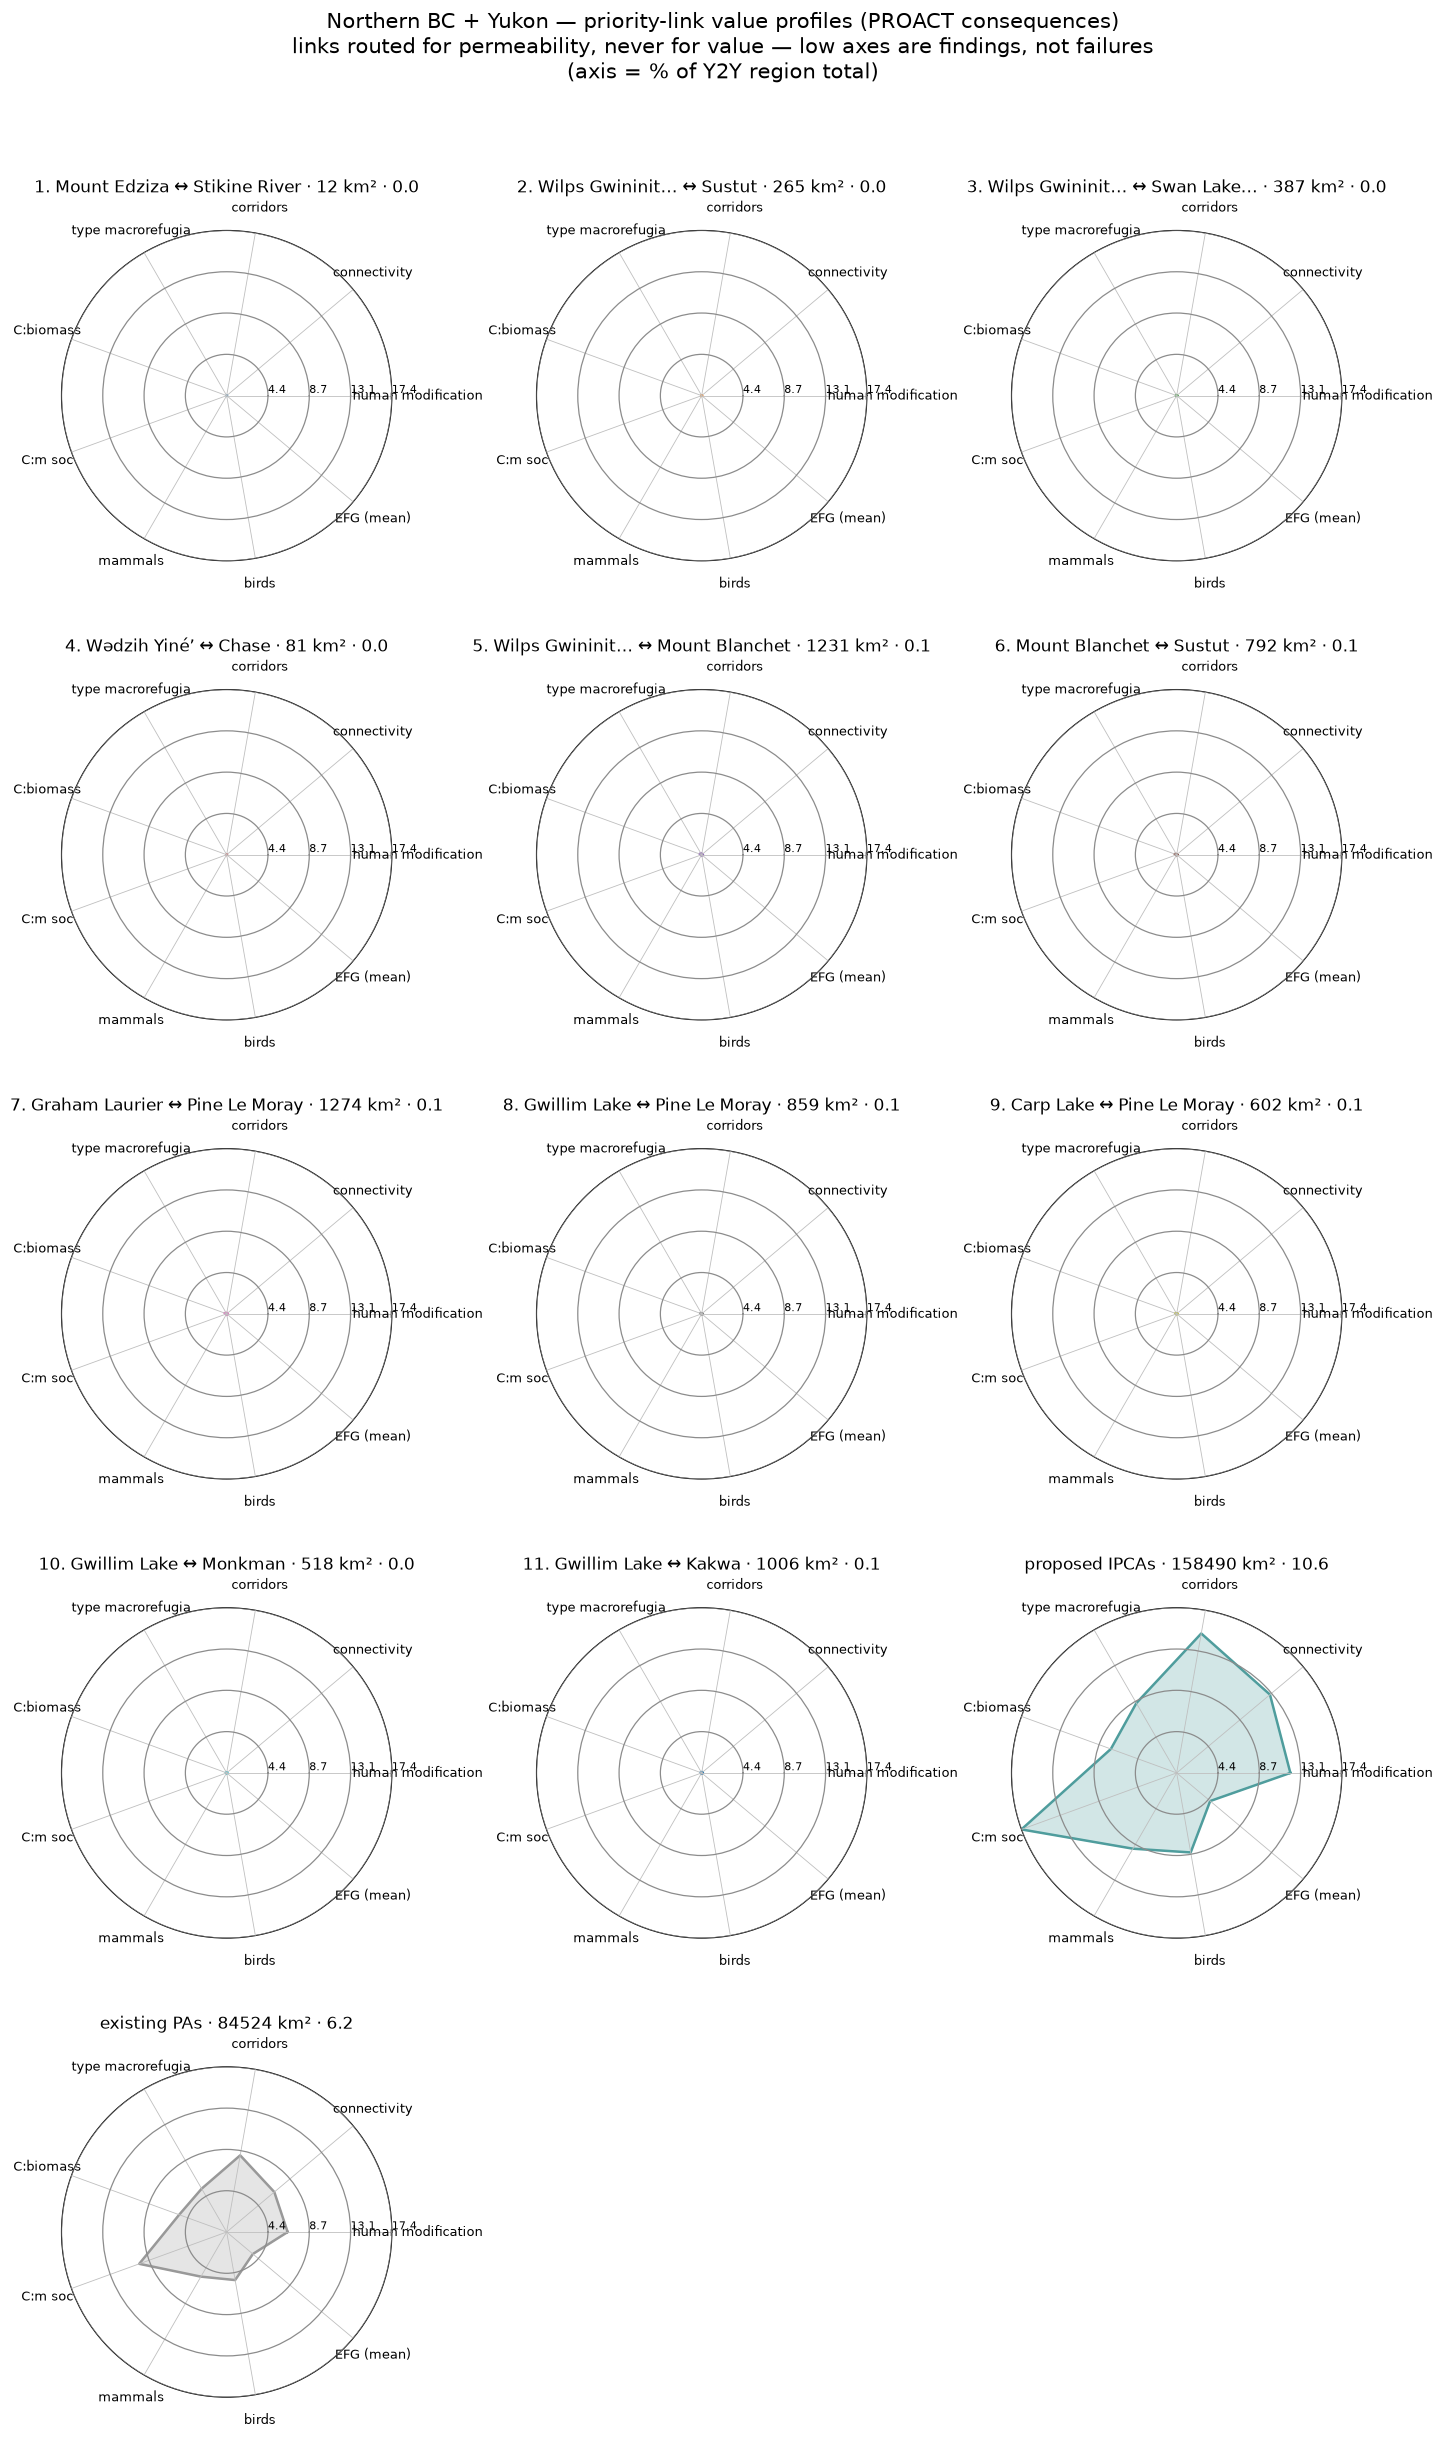

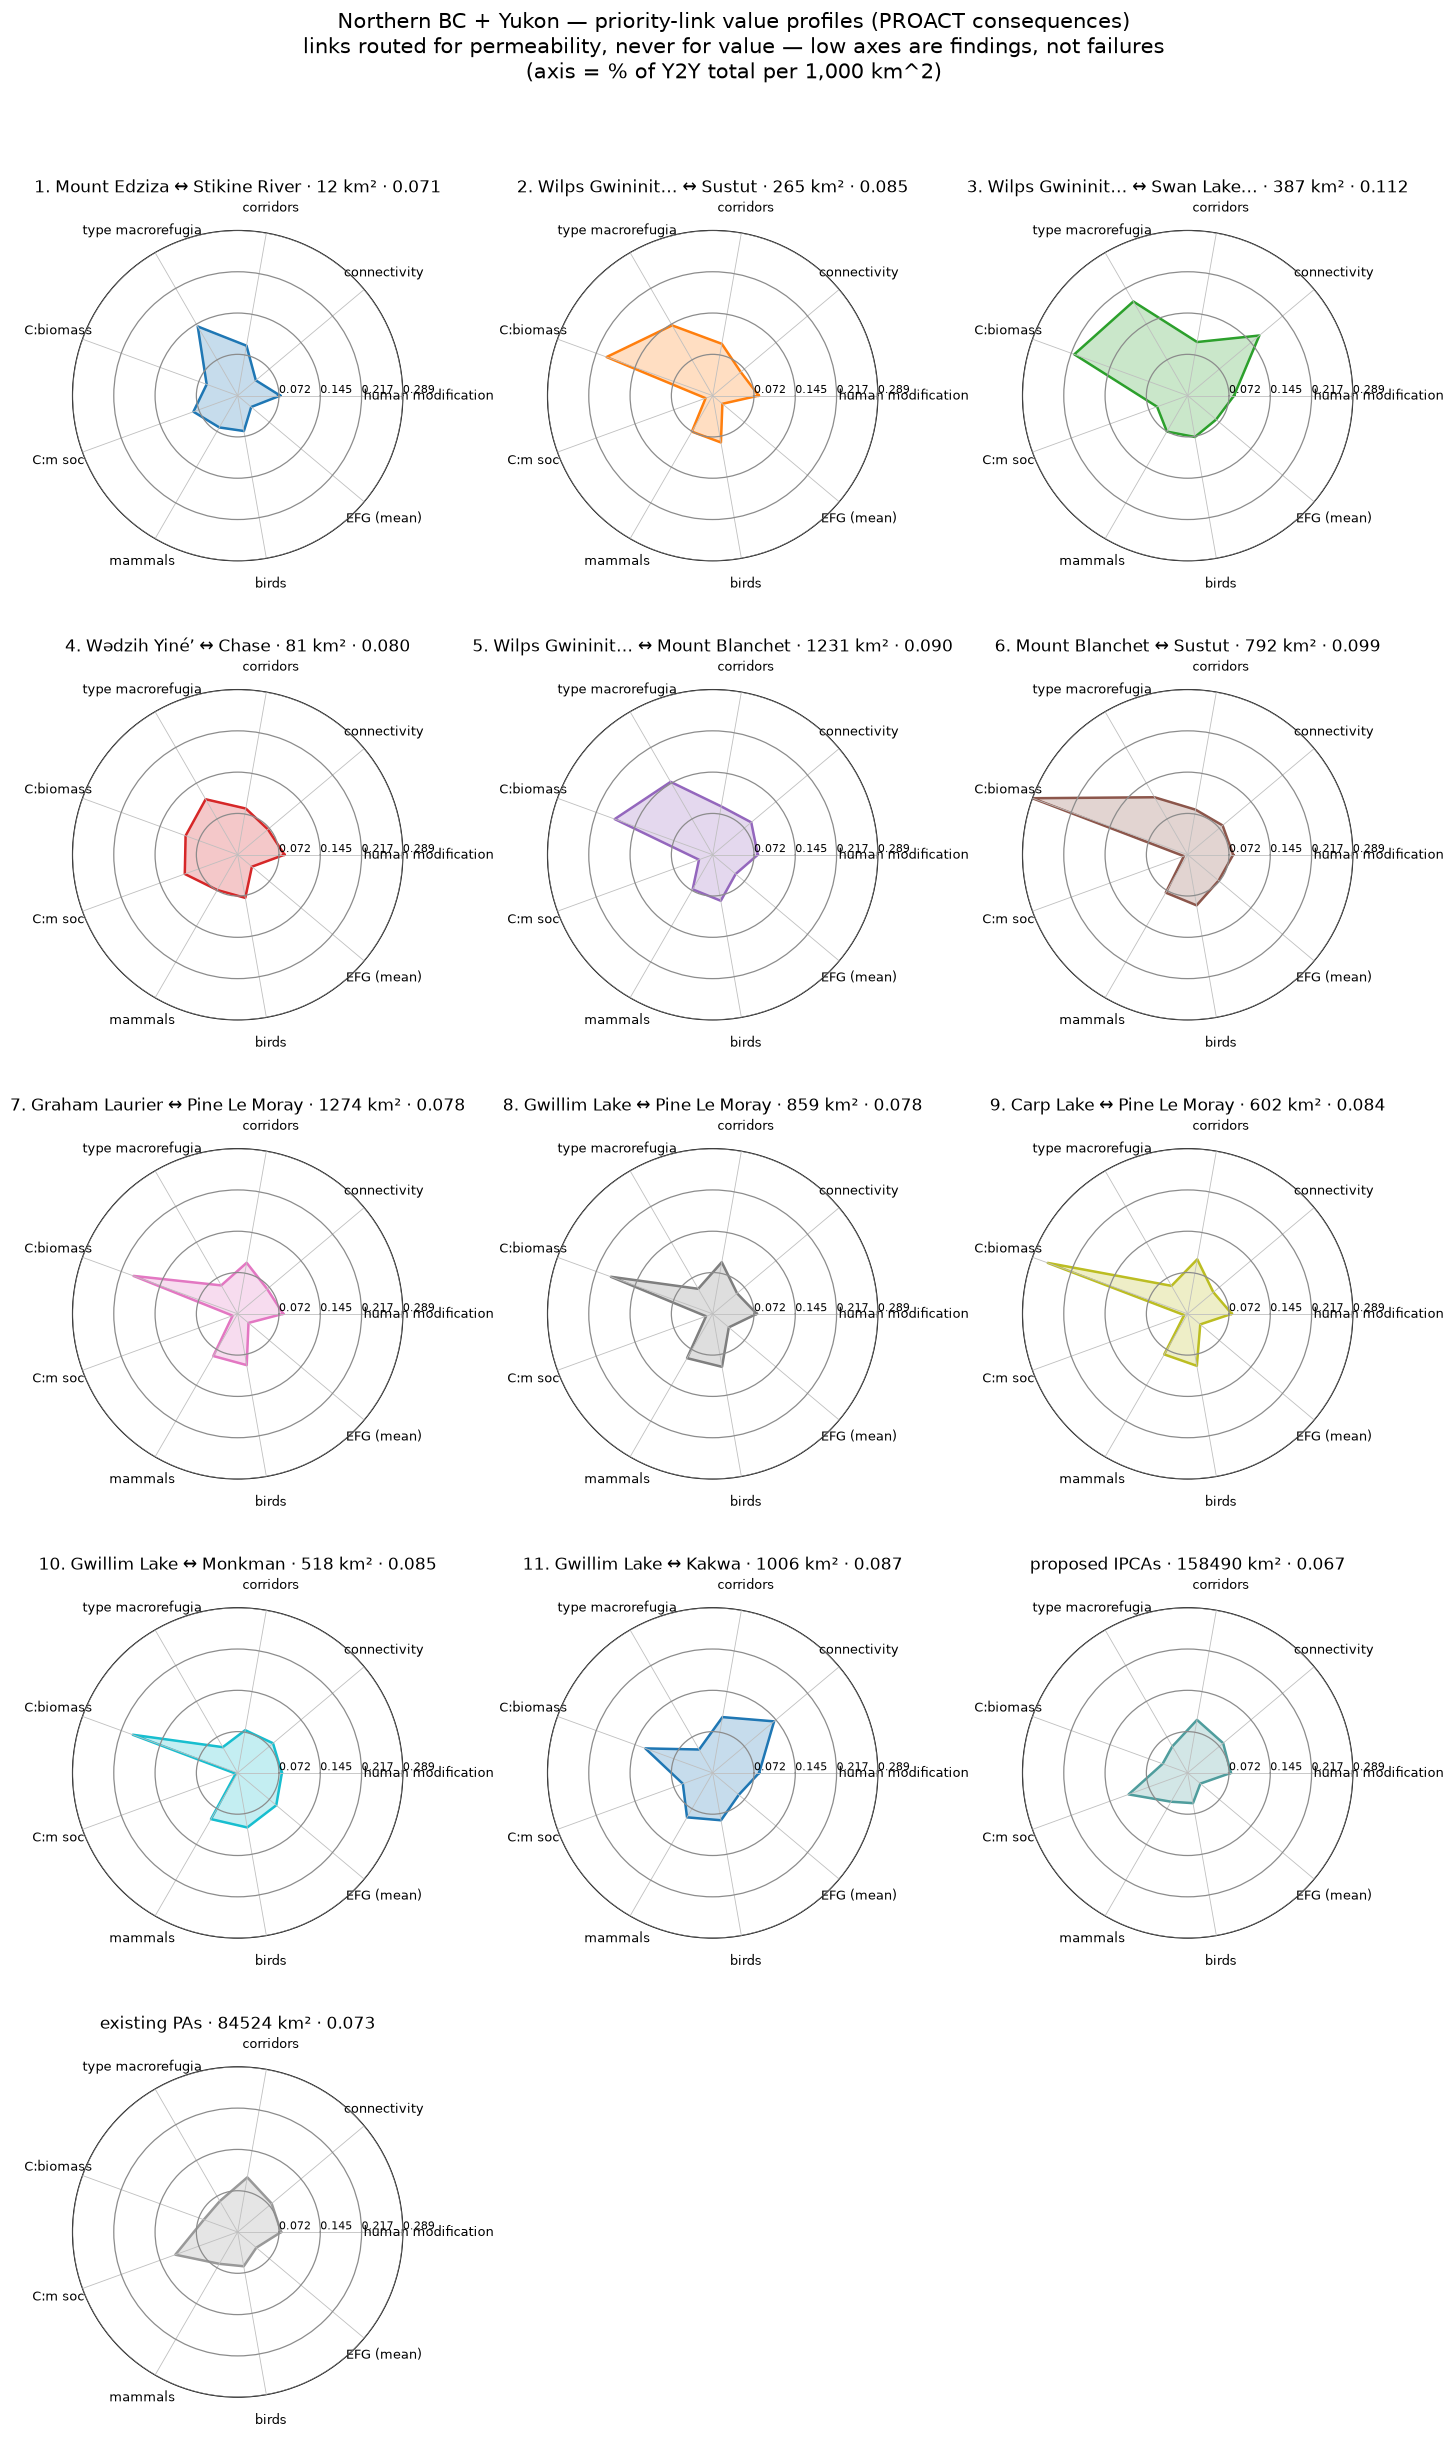

  wrote priority_links_profile.csv (13 rows) + priority_links_stars_*.png


,area,km2,km2_audit_grid,pct_y2y,human modification | richness,transboundary connectivity | richness,climate corridors | richness,climate type macrorefugia | richness,irrecoverable carbon biomass | richness,irrecoverable carbon m soc | richness,...,EFG (mean) | efficiency,human modification | raw [intactness 0-1 (mean; 1-gHM)],"transboundary connectivity | raw [current density, amperes (mean)]","climate corridors | raw [current-flow centrality, amperes (mean)]",climate type macrorefugia | raw [yr/km (mean; refugial residence = 1/backward velocity)],irrecoverable carbon biomass | raw [t C (total)],irrecoverable carbon m soc | raw [t C (total)],aoh richness mammals | raw [species/cell (mean)],aoh richness birds | raw [species/cell (mean)],EFG (mean) | raw [groups present (of 20)]
0,1. Mount Edziza ↔ Stikine River,13,12,0.001,0.893,0.154,0.455,0.636,0.209,0.209,...,0.031,0.978,1.07,8.13,0.82,18633.0,7.640800e+04,30.6,58.9,5.0
1,2. Wilps Gwininit… ↔ Sustut,269,265,0.021,0.869,0.291,0.350,0.891,0.624,0.031,...,0.022,0.971,1.52,7.74,0.76,1407142.0,2.693700e+05,31.8,71.4,5.0
2,3. Wilps Gwininit… ↔ Swan Lake…,366,387,0.030,0.977,0.862,0.448,0.907,0.639,0.134,...,0.065,0.991,3.93,8.11,1.04,2197107.0,1.702744e+06,32.2,63.9,6.0
3,4. Wədzih Yiné’ ↔ Chase,79,81,0.006,0.953,0.325,0.129,0.683,0.322,0.229,...,0.033,0.987,1.64,6.90,0.60,211204.0,6.166910e+05,31.2,65.8,5.0
4,5. Wilps Gwininit… ↔ Mount Blanchet,1175,1231,0.097,0.861,0.474,0.250,0.962,0.595,0.060,...,0.053,0.969,2.13,7.35,0.81,6036138.0,2.426062e+06,31.1,71.5,7.0
5,6. Mount Blanchet ↔ Sustut,753,792,0.062,0.802,0.402,0.087,0.716,0.860,0.017,...,0.071,0.959,1.89,6.72,0.62,6155280.0,4.362690e+05,33.5,77.2,6.0
6,7. Graham Laurier ↔ Pine Le Moray,1232,1274,0.100,0.790,0.313,0.340,0.239,0.632,0.022,...,0.025,0.960,1.60,7.62,0.31,6644620.0,9.280780e+05,37.3,78.3,7.0
7,8. Gwillim Lake ↔ Pine Le Moray,837,859,0.067,0.674,0.230,0.341,0.183,0.613,0.029,...,0.037,0.930,1.32,7.71,0.27,4376866.0,8.225120e+05,39.2,80.9,7.0
8,9. Carp Lake ↔ Pine Le Moray,587,602,0.047,0.700,0.251,0.461,0.232,0.796,0.015,...,0.029,0.931,1.39,8.14,0.30,4217760.0,3.004570e+05,35.8,79.4,6.0
9,10. Gwillim Lake ↔ Monkman,515,518,0.041,0.682,0.408,0.060,0.195,0.646,0.009,...,0.088,0.933,1.91,6.38,0.28,2719312.0,1.467410e+05,40.8,83.2,7.0


In [13]:
links_df = cc.priority_link_stars(R)
links_df


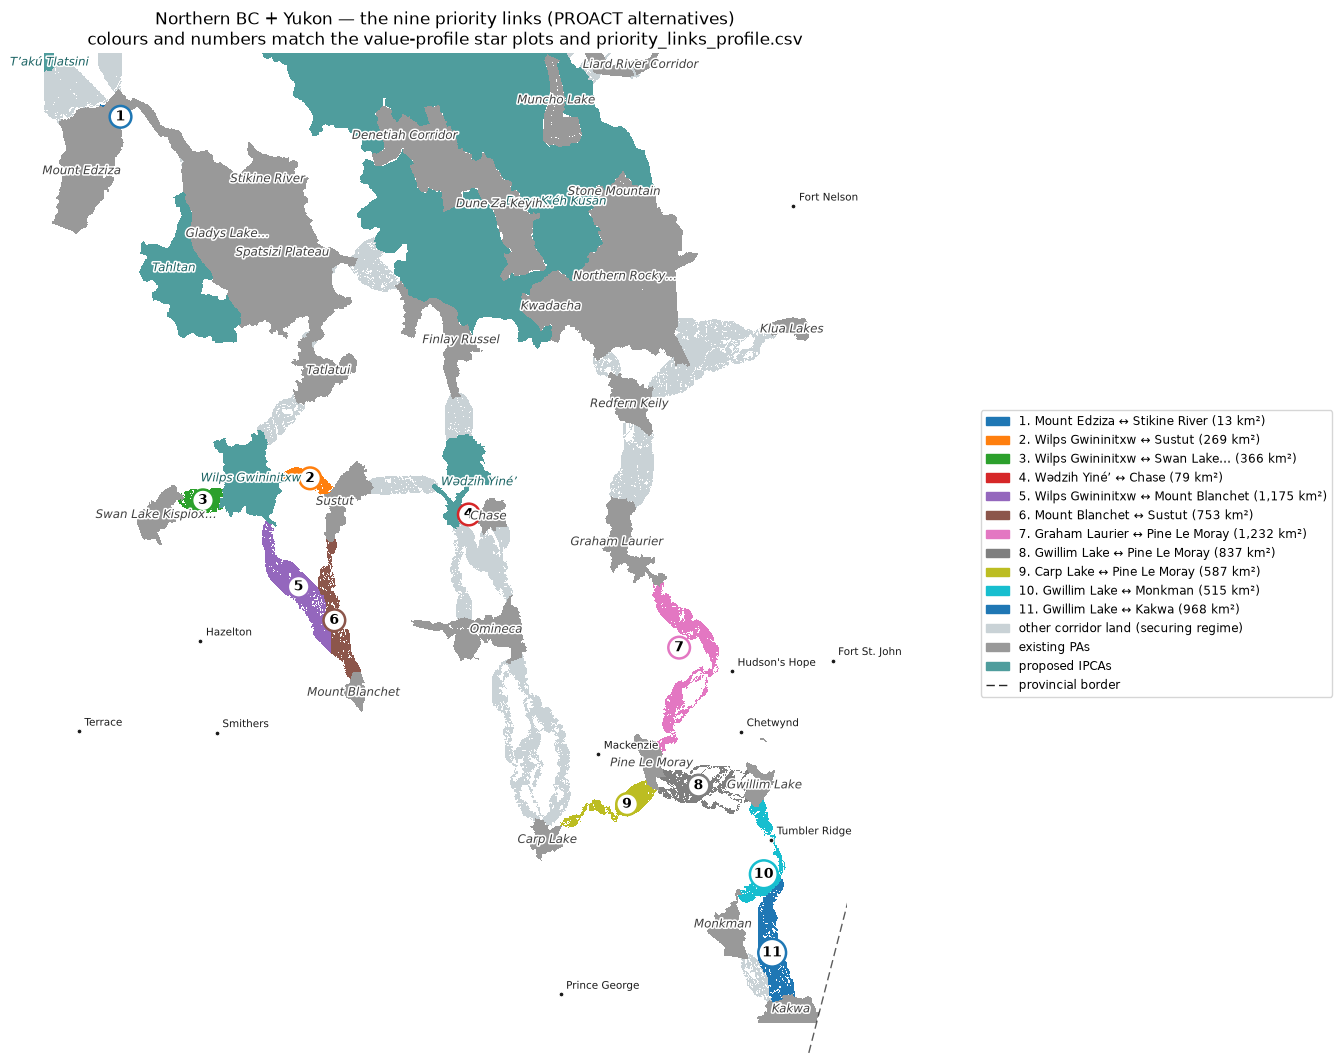

<corridors v2_run002 | 2809x5767 | 58 edges | corridor 33,041 km²>

In [14]:
# the framing-1 companion map: each link's OWNED corridor land in its star-plot colour
cc.priority_links_map(R)
